Nama Anggota :
- Muhamad Rafi Raditya (24523231)
- Ahmad Dzaky Al Farras (24523280)
- Muhammad Rangga Pratama (24523042)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_kebahagiaan_2019 = pd.read_csv('/content/sample_data/Kebahagiaan2019.csv')
display(df_kebahagiaan_2019.head())

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


## 1. Memahami dataset dan target klasifikasi

menampilkan informasi dasar dan statistik deskriptif dari dataset `df_kebahagiaan_2019`.

In [ ]:
print('Informasi Dataset:')
df_kebahagiaan_2019.info()

print('\nStatistik Deskriptif:')
display(df_kebahagiaan_2019.describe())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB

Statistik Deskriptif:


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [ ]:
median_score = df_kebahagiaan_2019['Score'].median()
df_kebahagiaan_2019['High_Happiness'] = (df_kebahagiaan_2019['Score'] > median_score).astype(int)

print(f"Median Score: {median_score}")
print("Value counts for 'High_Happiness':")
display(df_kebahagiaan_2019['High_Happiness'].value_counts())

Median Score: 5.3795
Value counts for 'High_Happiness':


,count
High_Happiness,
1,78
0,78


## 2. Preprocessing Data

In [ ]:
features = [
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

X = df_kebahagiaan_2019[features]
y = df_kebahagiaan_2019['High_Happiness']

print("Fitur (X) pertama:")
display(X.head())
print("\nTarget (y) pertama:")
display(y.head())

Fitur (X) pertama:


,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1.340,1.587,0.986,0.596,0.153,0.393
1,1.383,1.573,0.996,0.592,0.252,0.410
2,1.488,1.582,1.028,0.603,0.271,0.341
3,1.380,1.624,1.026,0.591,0.354,0.118
4,1.396,1.522,0.999,0.557,0.322,0.298



Target (y) pertama:


,High_Happiness
0,1
1,1
2,1
3,1
4,1


menentukan fitur (`X`) dan variabel target (`y`). Untuk fitur, menggunakan semua kolom numerik kecuali 'Overall rank' dan 'Score' (karena 'Score' digunakan untuk membuat target).

## 3. Pembagian Data Training dan Testing

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

Ukuran X_train: (124, 6)
Ukuran X_test: (32, 6)
Ukuran y_train: (124,)
Ukuran y_test: (32,)


## 4. Membangun Model Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Inisialisasi model Logistic Regression
model_lr = LogisticRegression(random_state=42, solver='liblinear') # Gunakan solver 'liblinear' untuk dataset kecil

# Latih model menggunakan data training
model_lr.fit(X_train, y_train)

print("Model Logistic Regression berhasil dilatih.")

Model Logistic Regression berhasil dilatih.


### 5. Evaluasi Model

In [ ]:
# Lakukan prediksi pada data test
y_pred = model_lr.predict(X_test)

# Evaluasi performa model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
display(pd.DataFrame(conf_matrix, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7812
Precision: 0.6818
Recall: 1.0000
F1-Score: 0.8108

Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,10,7
Actual 1,0,15



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.59      0.74        17
           1       0.68      1.00      0.81        15

    accuracy                           0.78        32
   macro avg       0.84      0.79      0.78        32
weighted avg       0.85      0.78      0.77        32



In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.59      0.74        17
           1       0.68      1.00      0.81        15

    accuracy                           0.78        32
   macro avg       0.84      0.79      0.78        32
weighted avg       0.85      0.78      0.77        32



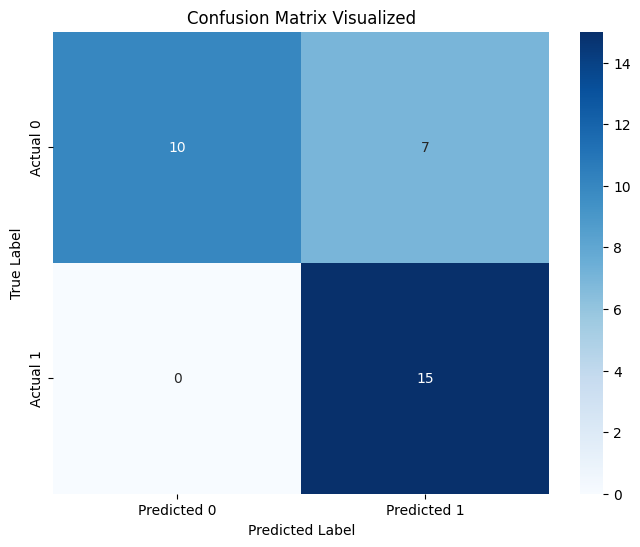

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Visualized')
plt.show()

## 6. Perbandingan Hasil Prediksi dan Aktual

Bagian ini bertujuan untuk membandingkan secara langsung nilai aktual (`y_test`) dengan nilai yang diprediksi oleh model (`y_pred`) untuk beberapa sampel pertama dari data uji. Dengan melihat tabel perbandingan ini, kita bisa mendapatkan gambaran awal tentang seberapa baik model Logistic Regression kita dalam membuat prediksi untuk setiap data poin:

- Kolom 'Actual' menunjukkan label kebahagiaan sesungguhnya (0 atau 1) dari data uji.
- Kolom 'Predicted' menunjukkan label kebahagiaan yang diprediksi oleh model Logistic Regression.

Pengecekan ini membantu kita memahami kasus-kasus di mana model berhasil memprediksi dengan benar dan di mana ia mungkin melakukan kesalahan, memberikan wawasan kualitatif tentang kinerja model di luar metrik kuantitatif seperti akurasi.

In [ ]:
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
display(comparison_df.head(10))

,Actual,Predicted
96,0,1
69,1,1
82,0,1
76,1,1
114,0,0
29,1,1
94,0,0
132,0,0
93,0,1
139,0,0


# 7. Analisis



### 1. Bagaimana kinerja model berdasarkan classification report?
Berdasarkan Classification Report yang dihasilkan:

Kelas 0 (Low Happiness):

Precision: 1.00 (atau 100%). Ini berarti semua negara yang diprediksi memiliki 'Low Happiness' (kelas 0) oleh model memang benar-benar memiliki 'Low Happiness'. Tidak ada False Positive untuk kelas ini.
Recall: 0.59 (atau 59%). Ini berarti dari semua negara yang sebenarnya memiliki 'Low Happiness', model hanya berhasil mengidentifikasi 59% di antaranya. Ada 41% False Negative, artinya beberapa negara 'Low Happiness' keliru diprediksi sebagai 'High Happiness'.
F1-Score: 0.74. F1-score adalah rata-rata harmonik dari precision dan recall, memberikan ukuran keseimbangan kedua metrik. Untuk kelas 0, nilai ini cukup baik.
Support: 17. Ada 17 sampel aktual untuk kelas 0 di data test.
Kelas 1 (High Happiness):

Precision: 0.68 (atau 68%). Ini berarti dari semua negara yang diprediksi memiliki 'High Happiness' (kelas 1), hanya 68% yang benar-benar memiliki 'High Happiness'. Ada 32% False Positive, artinya beberapa negara 'Low Happiness' keliru diprediksi sebagai 'High Happiness'.
Recall: 1.00 (atau 100%). Ini berarti dari semua negara yang sebenarnya memiliki 'High Happiness', model berhasil mengidentifikasi semuanya. Tidak ada False Negative untuk kelas ini.
F1-Score: 0.81. Ini adalah nilai F1-score yang sangat baik untuk kelas 1.
Support: 15. Ada 15 sampel aktual untuk kelas 1 di data test.
Overall Metrics:

Accuracy: 0.78 (atau 78%). Ini adalah proporsi prediksi benar dari total prediksi. Secara keseluruhan, model memprediksi dengan benar 78% dari waktu.
Macro Avg: Precision 0.84, Recall 0.79, F1-Score 0.78. Ini adalah rata-rata metrik tanpa memperhitungkan ketidakseimbangan kelas.
Weighted Avg: Precision 0.85, Recall 0.78, F1-Score 0.77. Ini adalah rata-rata metrik yang mempertimbangkan jumlah sampel di setiap kelas.

### 2. Apa makna True Positive, False Positive, True Negative, dan False Negative pada  studi kasus yang Anda pilih?

Dalam studi kasus klasifikasi kebahagiaan (di mana 0 = 'Low Happiness' dan 1 = 'High Happiness'), makna istilah-istilah tersebut adalah:

True Positive (TP): Model memprediksi 'High Happiness' (kelas 1) dan memang benar negara tersebut memiliki 'High Happiness'.

Dari Confusion Matrix: Ada 15 TP (dari baris 'Actual 1', kolom 'Predicted 1'). Ini berarti semua 15 negara yang benar-benar 'High Happiness' berhasil diprediksi dengan benar oleh model.

False Positive (FP): Model memprediksi 'High Happiness' (kelas 1) tetapi salah, negara tersebut sebenarnya memiliki 'Low Happiness'. Ini juga dikenal sebagai Type I Error.

Dari Confusion Matrix: Ada 7 FP (dari baris 'Actual 0', kolom 'Predicted 1'). Ini berarti 7 negara yang sebenarnya 'Low Happiness' keliru diklasifikasikan sebagai 'High Happiness'.

True Negative (TN): Model memprediksi 'Low Happiness' (kelas 0) dan memang benar negara tersebut memiliki 'Low Happiness'.

Dari Confusion Matrix: Ada 10 TN (dari baris 'Actual 0', kolom 'Predicted 0'). Ini berarti 10 negara yang benar-benar 'Low Happiness' berhasil diprediksi dengan benar.

False Negative (FN): Model memprediksi 'Low Happiness' (kelas 0) tetapi salah, negara tersebut sebenarnya memiliki 'High Happiness'. Ini juga dikenal sebagai Type II Error.

Dari Confusion Matrix: Ada 0 FN (dari baris 'Actual 1', kolom 'Predicted 0'). Ini sangat baik, artinya model tidak pernah melewatkan negara 'High Happiness' dan mengklasifikasikannya sebagai 'Low Happiness'.

### 3. Berikan kesimpulan mengenai seberapa baik Logistic Regression bekerja pada dataset yang digunakan.

Secara keseluruhan, model Logistic Regression menunjukkan kinerja yang cukup baik pada dataset ini, terutama dalam mengidentifikasi kelas 'High Happiness'.

Kekuatan:
Model sangat baik dalam mengidentifikasi negara-negara 'High Happiness' (Recall 1.00 untuk kelas 1). Ini berarti model tidak pernah salah mengklasifikasikan negara 'High Happiness' sebagai 'Low Happiness', yang bisa menjadi penting tergantung pada tujuan aplikasi.
Model juga memiliki precision yang sempurna untuk kelas 'Low Happiness' (Precision 1.00 untuk kelas 0), yang berarti setiap kali model mengatakan sebuah negara memiliki 'Low Happiness', itu selalu benar.

Kelemahan:
Kelemahan utama model ini adalah kecenderungannya untuk membuat False Positives yang signifikan untuk kelas 'High Happiness' (atau False Negatives untuk kelas 'Low Happiness'). Dengan kata lain, model cenderung terlalu optimis dan mengklasifikasikan beberapa negara 'Low Happiness' sebagai 'High Happiness'. Recall yang relatif rendah (0.59) untuk kelas 'Low Happiness' menunjukkan bahwa model kesulitan menemukan semua negara yang seharusnya masuk kategori 'Low Happiness'.


Kesimpulan: Model ini mungkin akan sangat berguna jika prioritas utamanya adalah memastikan tidak ada negara 'High Happiness' yang terlewatkan (karena recall 1.00 untuk kelas 1). Namun, jika penting untuk secara akurat mengidentifikasi negara-negara 'Low Happiness' tanpa mengklasifikasikan negara 'Low Happiness' sebagai 'High Happiness', model ini masih memerlukan peningkatan. Keseimbangan antara precision dan recall dapat ditingkatkan lebih lanjut, mungkin dengan tuning parameter model, atau mengeksplorasi algoritma klasifikasi lain, atau menambahkan fitur baru.
